# Proyecto ML - Clasificación de Comentarios Acusatorios

**Curso:** Machine Learning - Semestre 8

**Autores:** James Soto y Juan Diego Cadena

**Dataset:** Kapak (contratación pública)

In [14]:
# Instalación de dependencias y descarga del dataset
!pip install -q scikit-learn pandas matplotlib seaborn scipy openpyxl nltk sentence-transformers

import os

# Siempre re-descarga para evitar archivos corruptos de sesiones anteriores
!wget -q -O dataset.xlsx https://raw.githubusercontent.com/rosvjames/machineLearningProyecto/master/dataset.xlsx

# Verificar que el archivo sea un Excel válido (ZIP internamente)
import zipfile
if not zipfile.is_zipfile("dataset.xlsx"):
    raise RuntimeError("La descarga de dataset.xlsx falló o el archivo está corrupto. Verifica que esté en el repo.")
print("dataset.xlsx descargado y verificado correctamente.")

dataset.xlsx descargado y verificado correctamente.


In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Cargar dataset
df = pd.read_excel('dataset.xlsx', engine="openpyxl")

print(f"Shape del dataset: {df.shape}")
print(f"Columnas: {list(df.columns)}\n")
print(df.dtypes)
print("\n--- Primeras 5 filas ---")
df.head()

Shape del dataset: (5005, 5)
Columnas: ['contract_id', 'pregunta_id', 'pregunta', 'sum_pregunta_isAcusatoria', 'final_pregunta_isAcusatoria']

contract_id                    int64
pregunta_id                    int64
pregunta                         str
sum_pregunta_isAcusatoria      int64
final_pregunta_isAcusatoria    int64
dtype: object

--- Primeras 5 filas ---


,contract_id,pregunta_id,pregunta,sum_pregunta_isAcusatoria,final_pregunta_isAcusatoria
0,1345653,16756,Por favor requerimos se entregue un diagrama d...,0,0
1,1248857,16823,Indique de manera detallada y de manera taxati...,0,0
2,1350088,18197,4.En el punto 6 Información que dispone la ent...,0,0
3,682361,18263,Se puede ofertar un equipo que utilice cubetas...,0,0
4,1224444,18782,PODRIANN SUBIR UNA IMAGEN DEL SPAGUETTI ESPIRA...,0,0


## 1. Exploratory Data Analysis (EDA)




Distribución de clases:
  Clase 0 (No acusatoria): 4858 (97.06%)
  Clase 1 (Acusatoria):    147 (2.94%)
  Ratio desbalance:        33.0:1


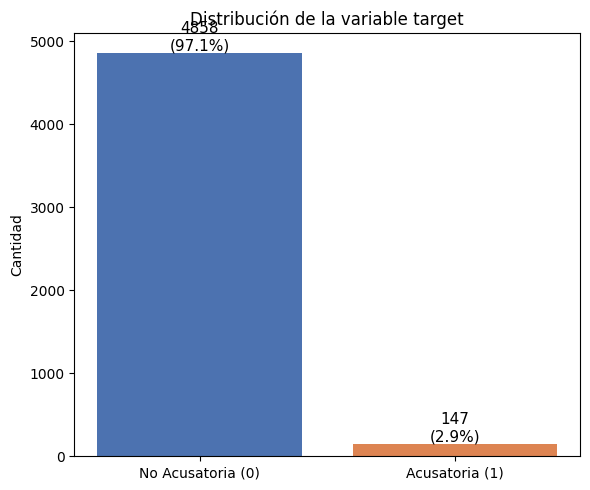

In [16]:
# --- 1.1 Distribución de clases ---
# Verificamos qué tan balanceada está la variable target.
# En clasificación binaria, un desbalance severo afecta el rendimiento
# de los modelos si no se maneja adecuadamente.

counts = df['final_pregunta_isAcusatoria'].value_counts()
percentages = df['final_pregunta_isAcusatoria'].value_counts(normalize=True) * 100

print("Distribución de clases:")
print(f"  Clase 0 (No acusatoria): {counts[0]} ({percentages[0]:.2f}%)")
print(f"  Clase 1 (Acusatoria):    {counts[1]} ({percentages[1]:.2f}%)")
print(f"  Ratio desbalance:        {counts[0]/counts[1]:.1f}:1")

fig, ax = plt.subplots(figsize=(6, 5))
bars = ax.bar(['No Acusatoria (0)', 'Acusatoria (1)'], counts.values,
              color=['#4C72B0', '#DD8452'])
for bar, count, pct in zip(bars, counts.values, percentages.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
            f'{count}\n({pct:.1f}%)', ha='center', fontsize=11)
ax.set_ylabel('Cantidad')
ax.set_title('Distribución de la variable target')
plt.tight_layout()
plt.show()

/tmp/ipykernel_73327/163384105.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='final_pregunta_isAcusatoria', y='longitud_texto', data=df, ax=axes[1],
/tmp/ipykernel_73327/163384105.py:21: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(['No Acusatoria (0)', 'Acusatoria (1)'])


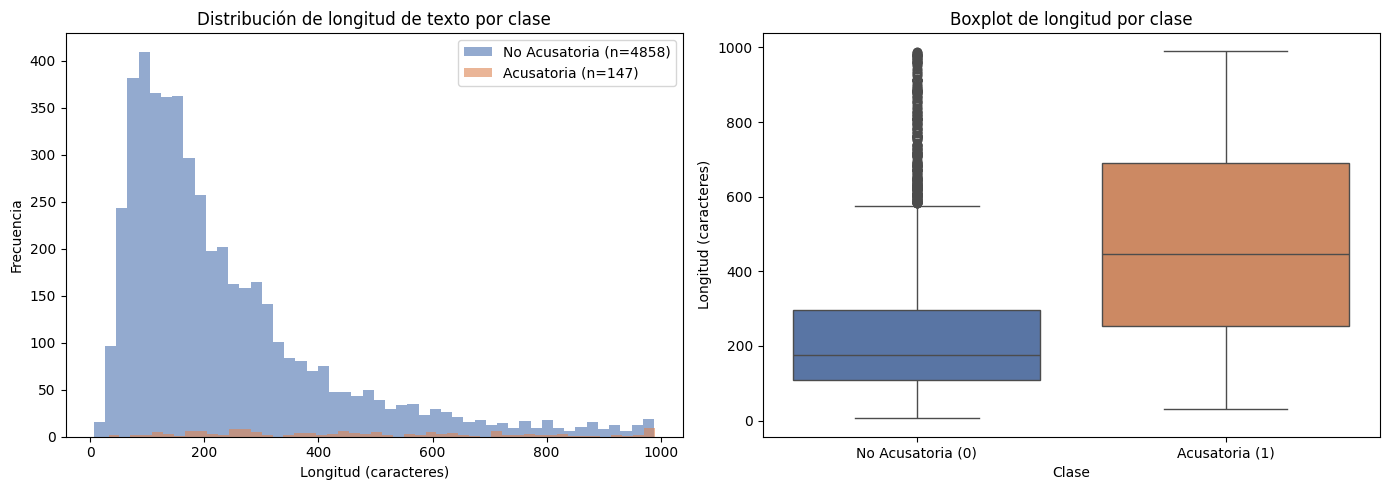

Estadísticas de longitud por clase:
                              count   mean    std   min    25%    50%    75%  \
final_pregunta_isAcusatoria                                                    
0                            4858.0  234.2  182.4   6.0  108.0  176.0  296.0   
1                             147.0  477.4  266.4  32.0  253.0  446.0  690.0   

                               max  
final_pregunta_isAcusatoria         
0                            988.0  
1                            990.0  


In [17]:
# --- 1.2 Distribución de longitudes de texto por clase ---
# Analizamos si las preguntas acusatorias tienden a ser más largas o cortas
# que las no acusatorias. Diferencias en longitud pueden ser un feature útil.

df['longitud_texto'] = df['pregunta'].str.len()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histograma superpuesto
for label, color, name in [(0, '#4C72B0', 'No Acusatoria'), (1, '#DD8452', 'Acusatoria')]:
    subset = df[df['final_pregunta_isAcusatoria'] == label]['longitud_texto']
    axes[0].hist(subset, bins=50, alpha=0.6, label=f'{name} (n={len(subset)})', color=color)
axes[0].set_xlabel('Longitud (caracteres)')
axes[0].set_ylabel('Frecuencia')
axes[0].set_title('Distribución de longitud de texto por clase')
axes[0].legend()

# Boxplot comparativo
sns.boxplot(x='final_pregunta_isAcusatoria', y='longitud_texto', data=df, ax=axes[1],
            palette=['#4C72B0', '#DD8452'])
axes[1].set_xticklabels(['No Acusatoria (0)', 'Acusatoria (1)'])
axes[1].set_xlabel('Clase')
axes[1].set_ylabel('Longitud (caracteres)')
axes[1].set_title('Boxplot de longitud por clase')

plt.tight_layout()
plt.show()

# Estadísticas descriptivas por clase
print("Estadísticas de longitud por clase:")
print(df.groupby('final_pregunta_isAcusatoria')['longitud_texto'].describe().round(1))

Valores únicos de sum_pregunta_isAcusatoria: [np.int64(0), np.int64(1), np.int64(2), np.int64(3)]

Distribución de votos:
sum_pregunta_isAcusatoria
0    4640
1     218
2      77
3      70
Name: count, dtype: int64


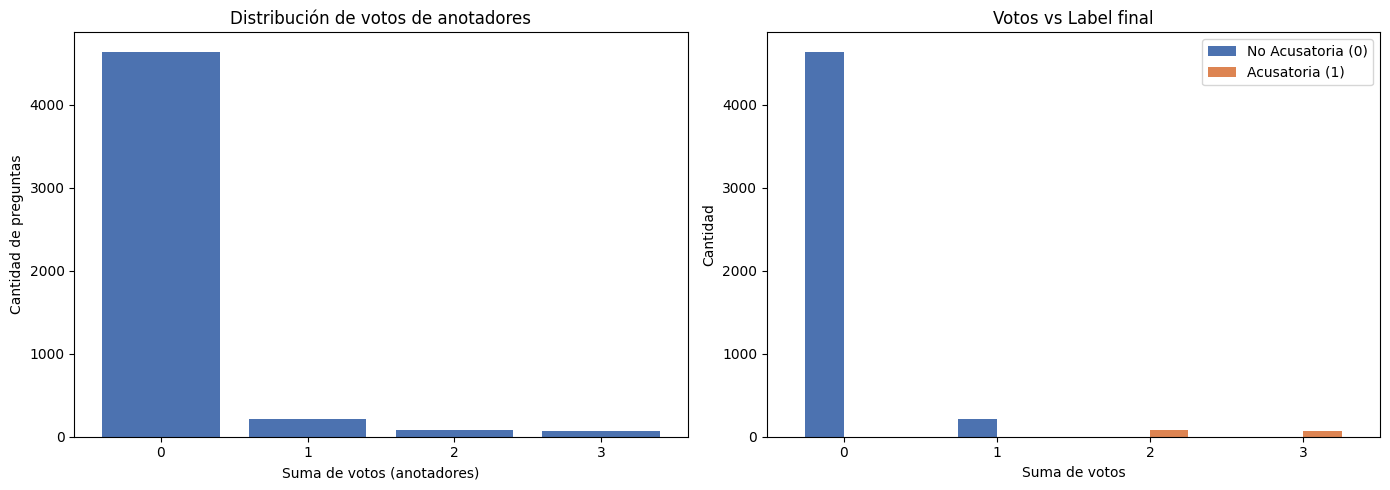


Tabla cruzada: sum_votos vs label final
final_pregunta_isAcusatoria     0    1  Total
sum_pregunta_isAcusatoria                    
0                            4640    0   4640
1                             218    0    218
2                               0   77     77
3                               0   70     70
Total                        4858  147   5005


In [18]:
# --- 1.3 Análisis de la columna 'sum_pregunta_isAcusatoria' ---
# Esta columna refleja la suma de votos de los anotadores humanos.
# Nos permite entender el proceso de etiquetado: cuántos anotadores
# coincidieron en clasificar cada pregunta como acusatoria.
# Un valor alto indica consenso fuerte; valores intermedios indican desacuerdo.

print("Valores únicos de sum_pregunta_isAcusatoria:", sorted(df['sum_pregunta_isAcusatoria'].unique()))
print("\nDistribución de votos:")
print(df['sum_pregunta_isAcusatoria'].value_counts().sort_index())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribución general de votos
vote_counts = df['sum_pregunta_isAcusatoria'].value_counts().sort_index()
axes[0].bar(vote_counts.index, vote_counts.values, color='#4C72B0')
axes[0].set_xlabel('Suma de votos (anotadores)')
axes[0].set_ylabel('Cantidad de preguntas')
axes[0].set_title('Distribución de votos de anotadores')
axes[0].set_xticks(vote_counts.index)

# Relación entre suma de votos y label final
cross = df.groupby(['sum_pregunta_isAcusatoria', 'final_pregunta_isAcusatoria']).size().unstack(fill_value=0)
cross.plot(kind='bar', ax=axes[1], color=['#4C72B0', '#DD8452'])
axes[1].set_xlabel('Suma de votos')
axes[1].set_ylabel('Cantidad')
axes[1].set_title('Votos vs Label final')
axes[1].legend(['No Acusatoria (0)', 'Acusatoria (1)'])
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

# Mostrar la tabla cruzada
print("\nTabla cruzada: sum_votos vs label final")
print(pd.crosstab(df['sum_pregunta_isAcusatoria'], df['final_pregunta_isAcusatoria'],
                  margins=True, margins_name='Total'))

In [19]:
# --- 1.4 Verificación de duplicados ---
# Verificamos si hay preguntas duplicadas en el texto.
# Los duplicados pueden inflar artificialmente las métricas si caen
# en train y test simultáneamente, por lo que es importante detectarlos.

duplicados_texto = df['pregunta'].duplicated().sum()
duplicados_total = df.duplicated().sum()

print(f"Duplicados en columna 'pregunta': {duplicados_texto}")
print(f"Filas completamente duplicadas:   {duplicados_total}")
print(f"Filas únicas por texto:           {df['pregunta'].nunique()} de {len(df)}")

if duplicados_texto > 0:
    print(f"\n--- Ejemplos de preguntas duplicadas ---")
    dup_mask = df['pregunta'].duplicated(keep=False)
    dup_examples = df[dup_mask].sort_values('pregunta').head(10)
    for _, row in dup_examples.iterrows():
        print(f"  [label={row['final_pregunta_isAcusatoria']}] {row['pregunta'][:100]}...")

# Verificar si hay duplicados con labels contradictorios
dup_preguntas = df.groupby('pregunta')['final_pregunta_isAcusatoria'].nunique()
contradictorios = (dup_preguntas > 1).sum()
print(f"\nPreguntas duplicadas con labels contradictorios: {contradictorios}")

Duplicados en columna 'pregunta': 147
Filas completamente duplicadas:   2
Filas únicas por texto:           4858 de 5005

--- Ejemplos de preguntas duplicadas ---
  [label=0] 1 ) Es necesario entregar las herramientas? 2)Cuántas personas se necesitan pararealizar laslabores ...
  [label=0] 1 ) Es necesario entregar las herramientas? 2)Cuántas personas se necesitan pararealizar laslabores ...
  [label=0] 1 ) ¿Es necesario entregar papel higiénico, jabón de tocador y dispensadores para estos, deser el ca...
  [label=0] 1 ) ¿Es necesario entregar papel higiénico, jabón de tocador y dispensadores para estos, deser el ca...
  [label=0] 1. ES OBLIGATORIA LA VISITA TÉCNICA? 2. Van a otorgar algún tipo de certificado para presentar enla ...
  [label=0] 1. ES OBLIGATORIA LA VISITA TÉCNICA? 2. Van a otorgar algún tipo de certificado para presentar enla ...
  [label=0] 1. ES OBLIGATORIA LA VISITA TÉCNICA? 2. Van a otorgar algún tipo de certificado para presentar enla ...
  [label=0] 1. ES OBLIGAT

## 2. Preprocesamiento de Texto

In [20]:
# PROMPT: "Genera una función de preprocesamiento de texto en español: convertir a
# minúsculas, remover caracteres especiales pero mantener acentos y ñ, y remover
# stopwords en español. Aplícala a la columna 'pregunta'. Elimina duplicados si los
# hay. Haz el train/test split estratificado (80/20) con random_state=42."

import re
import nltk
from nltk.corpus import stopwords
from sklearn.model_selection import train_test_split

nltk.download('stopwords', quiet=True)

# Stopwords híbridas: conservamos palabras que cargan tono acusatorio en español.
# Negaciones ("no", "ni"), interrogativos ("cómo", "hasta"), modales ("se", "debe")
# y adversativos ("pero") son discriminativos para detectar preguntas acusatorias.
KEEP = {
    'no', 'ni', 'nunca', 'jamás', 'tampoco', 'sin',
    'cómo', 'cuándo', 'por', 'qué', 'cuál', 'hasta',
    'se', 'si', 'puede', 'debe', 'pero', 'aunque'
}
custom_stopwords = set(stopwords.words('spanish')) - KEEP

def clean_text(text):
    text = text.lower()
    # Mantener letras (incluye acentos á é í ó ú ü y ñ), números y espacios
    text = re.sub(r'[^a-záéíóúüñ0-9\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    tokens = text.split()
    tokens = [t for t in tokens if t not in custom_stopwords]
    return ' '.join(tokens)

# Aplicar limpieza al dataset completo (operación determinista: no aprende del corpus)
df['pregunta_clean'] = df['pregunta'].apply(clean_text)

# Deduplicar sobre 'pregunta' (texto original) ANTES del split.
# Se usa el texto original — no el limpio — para que ambos pipelines reciban
# un trato neutral: Pipeline A trabaja con pregunta_clean y Pipeline B con pregunta.
# Deduplicar sobre pregunta_clean sería más agresivo (eliminaría variantes
# ortográficas que Pipeline B podría distinguir) y favorecería artificialmente
# a Pipeline A. Deduplicar sobre pregunta original elimina solo textos
# verdaderamente idénticos, sin sesgar la evaluación comparativa.
# Todos los duplicados tienen el mismo label (0 contradictorios), por lo que
# no hay riesgo de inconsistencia en el etiquetado.
df_clean = df.drop_duplicates(subset='pregunta').reset_index(drop=True)
print(f"Filas originales:          {len(df)}")
print(f"Tras eliminar duplicados:  {len(df_clean)}")
print(f"Duplicados removidos:      {len(df) - len(df_clean)}")

X = df_clean['pregunta_clean']
y = df_clean['final_pregunta_isAcusatoria']

# Split estratificado 80/20
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print(f"\nTrain: {len(X_train)} muestras | Test: {len(X_test)} muestras")
print(f"Clase 1 en train: {y_train.sum()} ({y_train.mean()*100:.1f}%)")
print(f"Clase 1 en test:  {y_test.sum()} ({y_test.mean()*100:.1f}%)")
print(f"\nEjemplo de texto limpio:")
print(f"  Original: {df_clean['pregunta'].iloc[0][:80]}")
print(f"  Limpio:   {df_clean['pregunta_clean'].iloc[0][:80]}")

Filas originales:          5005
Tras eliminar duplicados:  4858
Duplicados removidos:      147

Train: 3886 muestras | Test: 972 muestras
Clase 1 en train: 114 (2.9%)
Clase 1 en test:  29 (3.0%)

Ejemplo de texto limpio:
  Original: Por favor requerimos se entregue un diagrama de la red de la EPMAPS donde se pue
  Limpio:   por favor requerimos se entregue diagrama red epmaps se puedan visualizar losanc


## 3. Pipeline A: TF-IDF + Regresión Logística

In [21]:
# Imports generales para los pipelines
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import RepeatedStratifiedKFold, cross_validate
from sklearn.metrics import RocCurveDisplay
from scipy.stats import wilcoxon

In [22]:
import joblib

CACHE_DIR = '/teamspace/studios/this_studio/proyectoML_cache/'
os.makedirs(CACHE_DIR, exist_ok=True)

FORCE_RECOMPUTE = False

def _cache_path(name):
    return os.path.join(CACHE_DIR, f"{name}.pkl")

def load_cache(name):
    path = _cache_path(name)
    if FORCE_RECOMPUTE or not os.path.exists(path):
        return None
    print(f"[cache] '{name}' cargado desde cache local")
    return joblib.load(path)

def save_cache(name, obj):
    joblib.dump(obj, _cache_path(name))
    print(f"[cache] '{name}' guardado en cache local")

print(f"\nCache activo en: {CACHE_DIR}")
print(f"FORCE_RECOMPUTE: {FORCE_RECOMPUTE}")


Cache activo en: /teamspace/studios/this_studio/proyectoML_cache/
FORCE_RECOMPUTE: False


In [23]:
# PROMPT: "Crea un Pipeline de sklearn con TfidfVectorizer (con parámetros para español)
# y LogisticRegression con class_weight='balanced'. Usa RepeatedStratifiedKFold
# (10 repeticiones, 10 folds) para evaluar con AUC-ROC como métrica principal.
# Guarda los scores de cada fold para usarlos después en el test estadístico."

pipeline_a = Pipeline([
    ('tfidf', TfidfVectorizer(ngram_range=(1,2), min_df=2, max_df=0.95)),
    ('clf',   LogisticRegression(max_iter=3000, class_weight='balanced', random_state=42))
])

# RepeatedStratifiedKFold 10x10: mantiene proporción 97/3 en cada fold y produce
# 100 scores para un test estadístico robusto posterior
rskf   = RepeatedStratifiedKFold(n_splits=10, n_repeats=10, random_state=42)
scoring = ['roc_auc', 'f1_macro', 'precision_macro', 'recall_macro', 'accuracy']

# Cache: evita recomputar las 100 evaluaciones si ya fueron hechas
cv_a = load_cache('cv_a')
if cv_a is None:
    cv_a = cross_validate(pipeline_a, X_train, y_train, cv=rskf, scoring=scoring)
    save_cache('cv_a', cv_a)

print("=== Pipeline A: TF-IDF + Logistic Regression ===")
metrics_display = {
    'AUC-ROC':   'roc_auc',
    'F1-Macro':  'f1_macro',
    'Precision': 'precision_macro',
    'Recall':    'recall_macro',
    'Accuracy':  'accuracy'
}
for name, key in metrics_display.items():
    s = cv_a[f'test_{key}']
    print(f"  {name:12s}: {s.mean():.4f} ± {s.std():.4f}")

print(f"\nTotal de folds evaluados: {len(cv_a['test_roc_auc'])} (10 splits × 10 repeats)")

[cache] 'cv_a' guardado en cache local
=== Pipeline A: TF-IDF + Logistic Regression ===
  AUC-ROC     : 0.9369 ± 0.0271
  F1-Macro    : 0.7060 ± 0.0633
  Precision   : 0.6933 ± 0.0639
  Recall      : 0.7297 ± 0.0764
  Accuracy    : 0.9629 ± 0.0090

Total de folds evaluados: 100 (10 splits × 10 repeats)


## 4. Optimización de Hiperparámetros — Pipeline A

In [24]:
# PROMPT: "Sobre el Pipeline A, haz GridSearchCV para optimizar el parámetro C de la
# regresión logística (prueba valores de 0.001 a 100 en escala log) y max_features del
# TfidfVectorizer. Usa RepeatedStratifiedKFold. Genera: 1) gráfica de C vs AUC-ROC."

from sklearn.model_selection import GridSearchCV

param_grid = {
    'clf__C':              [0.001, 0.01, 0.1, 1, 10, 100],
    'tfidf__max_features': [5000, 10000, None]   # None = sin límite
}

# Cache: GridSearch es la operación más pesada (~30 min). Guardamos el objeto
# completo para tener acceso a best_params_, best_score_ y cv_results_ sin recomputar
grid_search = load_cache('grid_search')
if grid_search is None:
    grid_search = GridSearchCV(
        pipeline_a,
        param_grid,
        cv=rskf,
        scoring='roc_auc',
        n_jobs=-1,
        verbose=1
    )
    grid_search.fit(X_train, y_train)
    save_cache('grid_search', grid_search)

print(f"Mejores parámetros:  {grid_search.best_params_}")
print(f"Mejor AUC-ROC (CV):  {grid_search.best_score_:.4f}")

pipeline_a_opt = grid_search.best_estimator_

Fitting 100 folds for each of 18 candidates, totalling 1800 fits
[cache] 'grid_search' guardado en cache local
Mejores parámetros:  {'clf__C': 1, 'tfidf__max_features': None}
Mejor AUC-ROC (CV):  0.9369


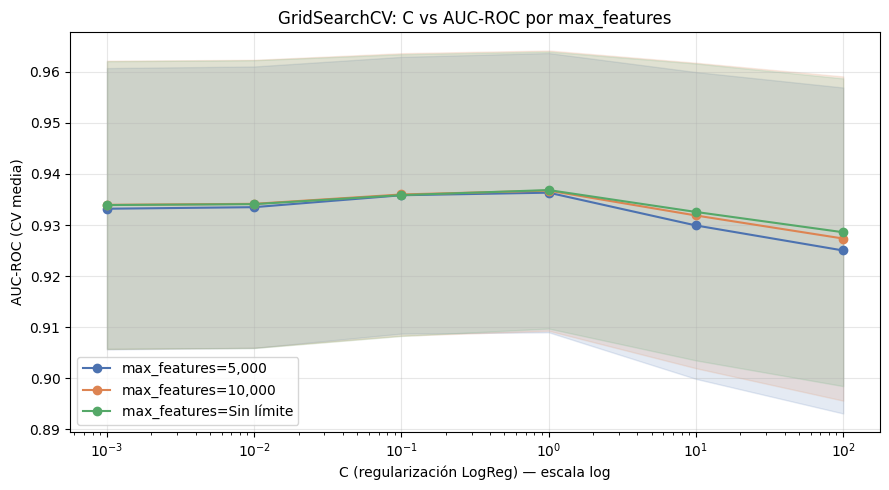

In [25]:
# --- Gráfica C vs AUC-ROC (para cada valor de max_features) ---
results = pd.DataFrame(grid_search.cv_results_)
max_features_vals = [5000, 10000, None]
labels            = ['5,000', '10,000', 'Sin límite']
colors            = ['#4C72B0', '#DD8452', '#55A868']
C_values          = [0.001, 0.01, 0.1, 1, 10, 100]

fig, ax = plt.subplots(figsize=(9, 5))
for mf, label, color in zip(max_features_vals, labels, colors):
    # None se almacena como NaN en el DataFrame — no se puede comparar con ==
    if mf is None:
        mask = results['param_tfidf__max_features'].isna()
    else:
        mask = results['param_tfidf__max_features'] == mf

    means = results.loc[mask, 'mean_test_score'].values
    stds  = results.loc[mask, 'std_test_score'].values
    ax.semilogx(C_values, means, marker='o', label=f'max_features={label}', color=color)
    ax.fill_between(C_values, means - stds, means + stds, alpha=0.15, color=color)

ax.set_xlabel('C (regularización LogReg) — escala log')
ax.set_ylabel('AUC-ROC (CV media)')
ax.set_title('GridSearchCV: C vs AUC-ROC por max_features')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

[cache] 'learning_curve' guardado en cache local


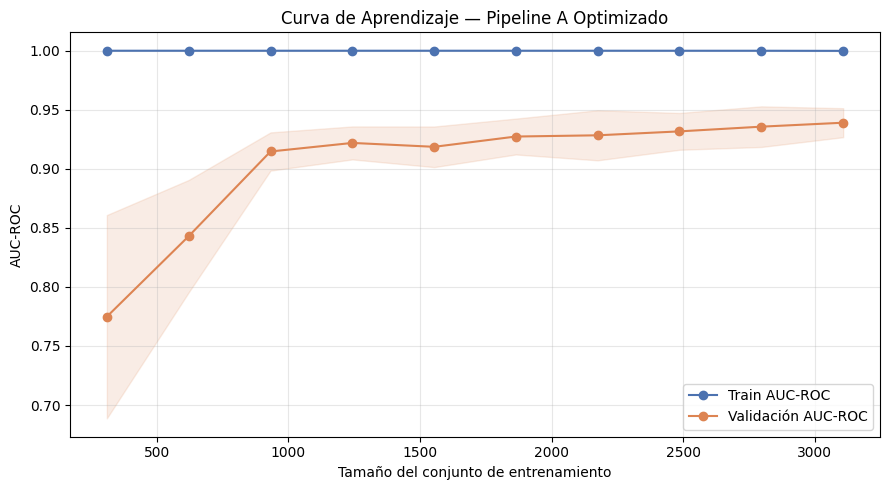

AUC-ROC train (100% datos): 0.9999
AUC-ROC val   (100% datos): 0.9391
Gap train-val:              0.0608 (overfitting leve)


In [26]:
# PROMPT: "Genera: 2) curva de aprendizaje con learning_curve de sklearn
# usando el pipeline optimizado."

from sklearn.model_selection import learning_curve, StratifiedKFold

# Cache: la curva de aprendizaje entrena el pipeline 50 veces (10 tamaños × 5 folds)
lc_data = load_cache('learning_curve')
if lc_data is None:
    train_sizes, train_scores, val_scores = learning_curve(
        pipeline_a_opt,
        X_train, y_train,
        cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
        scoring='roc_auc',
        train_sizes=np.linspace(0.1, 1.0, 10),
        n_jobs=-1
    )
    lc_data = {
        'train_sizes':  train_sizes,
        'train_scores': train_scores,
        'val_scores':   val_scores,
    }
    save_cache('learning_curve', lc_data)
else:
    train_sizes  = lc_data['train_sizes']
    train_scores = lc_data['train_scores']
    val_scores   = lc_data['val_scores']

train_mean = train_scores.mean(axis=1)
train_std  = train_scores.std(axis=1)
val_mean   = val_scores.mean(axis=1)
val_std    = val_scores.std(axis=1)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(train_sizes, train_mean, 'o-', color='#4C72B0', label='Train AUC-ROC')
ax.fill_between(train_sizes, train_mean - train_std, train_mean + train_std,
                alpha=0.15, color='#4C72B0')
ax.plot(train_sizes, val_mean, 'o-', color='#DD8452', label='Validación AUC-ROC')
ax.fill_between(train_sizes, val_mean - val_std, val_mean + val_std,
                alpha=0.15, color='#DD8452')

ax.set_xlabel('Tamaño del conjunto de entrenamiento')
ax.set_ylabel('AUC-ROC')
ax.set_title('Curva de Aprendizaje — Pipeline A Optimizado')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Gap final entre train y val
gap = train_mean[-1] - val_mean[-1]
print(f"AUC-ROC train (100% datos): {train_mean[-1]:.4f}")
print(f"AUC-ROC val   (100% datos): {val_mean[-1]:.4f}")
print(f"Gap train-val:              {gap:.4f} ({'overfitting leve' if gap > 0.05 else 'bien ajustado'})")

## 5. Pipeline B: Sentence Embeddings + SVM

In [27]:
# PROMPT: "Crea un segundo enfoque usando sentence-transformers
# (modelo 'paraphrase-multilingual-MiniLM-L12-v2') para generar embeddings
# de las preguntas. Luego entrena un clasificador SVM con class_weight='balanced'
# sobre esos embeddings. Evalúa con el mismo RepeatedStratifiedKFold y guarda
# los scores por fold."

# --- Celda 1: Generación de embeddings (separada para poder cachear) ---
from sentence_transformers import SentenceTransformer

# Cache: evita descargar el modelo (~471MB) y re-encodear todas las preguntas
emb_data = load_cache('embeddings')
if emb_data is None:
    # Usamos el texto original (df_clean) en vez del texto limpio: el modelo de
    # embeddings fue preentrenado con frases completas y se beneficia de tener
    # el texto sin remover stopwords
    emb_model = SentenceTransformer('sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2')

    X_train_emb = emb_model.encode(
        df_clean.loc[X_train.index, 'pregunta'].tolist(),
        show_progress_bar=False,
        batch_size=64
    )
    X_test_emb = emb_model.encode(
        df_clean.loc[X_test.index, 'pregunta'].tolist(),
        show_progress_bar=False,
        batch_size=64
    )
    save_cache('embeddings', {'train': X_train_emb, 'test': X_test_emb})
else:
    X_train_emb = emb_data['train']
    X_test_emb  = emb_data['test']

print(f"Shape embeddings train: {X_train_emb.shape}")
print(f"Shape embeddings test:  {X_test_emb.shape}")

/home/zeus/miniconda3/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 199/199 [00:00<00:00, 3711.69it/s]


[cache] 'embeddings' guardado en cache local
Shape embeddings train: (3886, 384)
Shape embeddings test:  (972, 384)


In [15]:
# --- Celda 2: SVM + RepeatedStratifiedKFold 10x10 ---
# Los embeddings son fijos (modelo preentrenado, no aprende del corpus),
# por lo que pasar X_train_emb directamente al CV no introduce leakage.

from sklearn.svm import SVC

pipeline_b = SVC(
    kernel='rbf',
    class_weight='balanced',
    probability=True,    # necesario para AUC-ROC y curva ROC posterior
    random_state=42
)

# Cache: SVM RBF con 100 folds es la operación más pesada del notebook (~30-45 min)
cv_b = load_cache('cv_b')
if cv_b is None:
    cv_b = cross_validate(pipeline_b, X_train_emb, y_train, cv=rskf, scoring=scoring)
    save_cache('cv_b', cv_b)

print("=== Pipeline B: Sentence Embeddings + SVM (RBF) ===")
for name, key in metrics_display.items():
    s = cv_b[f'test_{key}']
    print(f"  {name:12s}: {s.mean():.4f} ± {s.std():.4f}")

print(f"\nTotal de folds evaluados: {len(cv_b['test_roc_auc'])} (10 splits × 10 repeats)")

# Comparación rápida A vs B
print("\n--- Comparación rápida AUC-ROC ---")
auc_a = cv_a['test_roc_auc']
auc_b = cv_b['test_roc_auc']
print(f"  Pipeline A (TF-IDF + LogReg): {auc_a.mean():.4f} ± {auc_a.std():.4f}")
print(f"  Pipeline B (Emb  + SVM RBF):  {auc_b.mean():.4f} ± {auc_b.std():.4f}")

### 5.1 Optimización de Hiperparámetros — Pipeline B

Para que la comparación estadística del Paso 6 sea justa, optimizamos también Pipeline B con GridSearchCV sobre `C` (regularización del SVM) y `gamma` (coeficiente del kernel RBF).

In [ ]:
# PROMPT: "Optimiza Pipeline B con GridSearchCV sobre C y gamma del SVM RBF.
# Usa el mismo RepeatedStratifiedKFold 10x10 y AUC-ROC como métrica. Después
# re-evalúa el best_estimator con cross_validate para tener todas las métricas
# por fold (necesarias para comparación estadística del Paso 6)."

# Grid compacto para SVM RBF: 3 valores de C × 3 de gamma = 9 combinaciones
# (SVM RBF con probability=True es pesado, cada fit toma varios segundos)
param_grid_b = {
    'C':     [1, 10, 100],
    'gamma': ['scale', 'auto', 0.1]
}

grid_search_b = load_cache('grid_search_b')
if grid_search_b is None:
    svc_base = SVC(kernel='rbf', class_weight='balanced',
                   probability=True, random_state=42)
    grid_search_b = GridSearchCV(
        svc_base,
        param_grid_b,
        cv=rskf,
        scoring='roc_auc',
        n_jobs=-1,
        verbose=1
    )
    grid_search_b.fit(X_train_emb, y_train)
    save_cache('grid_search_b', grid_search_b)

print(f"Mejores parámetros B:  {grid_search_b.best_params_}")
print(f"Mejor AUC-ROC B (CV):  {grid_search_b.best_score_:.4f}")

pipeline_b_opt = grid_search_b.best_estimator_

# Re-evaluar con todas las métricas usando el pipeline óptimo
cv_b_opt = load_cache('cv_b_opt')
if cv_b_opt is None:
    cv_b_opt = cross_validate(pipeline_b_opt, X_train_emb, y_train,
                              cv=rskf, scoring=scoring)
    save_cache('cv_b_opt', cv_b_opt)

print("\n=== Pipeline B Optimizado ===")
for name, key in metrics_display.items():
    s = cv_b_opt[f'test_{key}']
    print(f"  {name:12s}: {s.mean():.4f} ± {s.std():.4f}")

# Comparación: B baseline vs B optimizado
print("\n--- Mejora por optimización en Pipeline B (AUC-ROC) ---")
print(f"  B baseline:   {cv_b['test_roc_auc'].mean():.4f} ± {cv_b['test_roc_auc'].std():.4f}")
print(f"  B optimizado: {cv_b_opt['test_roc_auc'].mean():.4f} ± {cv_b_opt['test_roc_auc'].std():.4f}")
delta = cv_b_opt['test_roc_auc'].mean() - cv_b['test_roc_auc'].mean()
print(f"  Mejora:       {delta:+.4f}")